# Capitolo 1: Analisi Spaziale e Topologica di FLUX.1
**Progetto FlowStitch: Estrazione di Planimetrie Architettoniche Latenti**

### Obiettivi della Ricerca
Il progetto **FlowStitch** si propone di investigare la natura deterministica dei modelli *Diffusion Transformer* (DiT), nello specifico **FLUX.1 [schnell]**, focalizzandosi sulla fase iniziale dell'inferenza ($t=0$).

L'ipotesi di ricerca fondamentale sostiene che il modello agisca come un "Architetto": definisce la geometria globale e topologica dell'immagine (Planimetria Architettonica) prima ancora di elaborare dettagli tessiturali o cromatici. L'obiettivo ultimo è la formulazione matematica del **Latent Stitching**: un paradigma per comporre immagini diverse operando manipolazioni dirette e non lineari sui tensori latenti predetti, superando i limiti delle tradizionali tecniche di inpainting.

### Architettura del Sistema di Estrazione
La fase di estrazione dati è stata eseguita su un nodo HPC (NVIDIA L40) utilizzando un sistema di *Forward Hooking* customizzato per l'ecosistema `diffusers`.

**Il Core Matematico (Flow Matching)**
FLUX.1 si basa sul framework del Flow Matching, in cui l'equazione fondamentale allo step iniziale è:
$$x_{pred} = x_0 + v_0$$
Dove $x_0 \sim \mathcal{N}(0, I)$ è il rumore gaussiano isotropo iniziale e $v_0$ è il campo vettoriale (velocità) predetto dal trasformer. Il tensore risultante $x_{pred}$ rappresenta la proiezione lineare dell'immagine finale nello spazio latente.

### Scopo del Capitolo 1
Questo notebook costituisce il punto di partenza dell'indagine. L'obiettivo è validare l'ipotesi architettonica analizzando empiricamente due grandezze fondamentali allo step 0:
1.  **La Cross-Attention Matrix:** Come il modello distribuisce l'attenzione visiva (condizionamento semantico).
2.  **Il Campo Vettoriale $v_0$:** Come l'energia termodinamica viene spesa per spostare i pixel dal rumore puro.

In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import T5Tokenizer

# Percorso principale del dataset
dataset_path = "../data/dataset_v1/"

# Identificazione dinamica dei prompt disponibili
available_prompts = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
available_prompts.sort()

print("Prompt disponibili nel dataset:")
for i, p in enumerate(available_prompts):
    print(f"[{i}] {p.replace('_', ' ')}")


Prompt disponibili nel dataset:
[0] a blue cube and a red sphere
[1] a blue sphere
[2] a blue sphere on the left a red cube on the right
[3] a crystal clear lake
[4] a majestic mountain
[5] a majestic mountain reflecting in a crystal clear 
[6] a red cube
[7] a red cube and a blue sphere
[8] a red cube on the left a blue sphere on the right
[9] a yellow pyramid


### Selezione del Prompt e Caricamento Mappe
Selezioniamo uno dei prompt per analizzare in che modo il modello ha allocato le sue risorse spaziali. Ti invitiamo a testare sia prompt singoli (es. `a red cube`) sia prompt compositi (es. `a blue sphere on the left a red cube on the right`) per osservare le differenze.


In [2]:
# SCEGLI L'INDICE DEL PROMPT DA ANALIZZARE (da 0 a 9)
PROMPT_INDEX = 0

prompt_folder = available_prompts[PROMPT_INDEX]
prompt_text = prompt_folder.replace("_", " ")
path = os.path.join(dataset_path, prompt_folder, "")

print(f"Analizzando il prompt: '{prompt_text}'")

# 1. Carica il Rumore Iniziale (x0) e la Velocità (v0) calcolata dal modello allo step 0
x0_noise = torch.load(path + "x0_noise.pt", weights_only=True)
v0_velocity = torch.load(path + "v0_velocity.pt", weights_only=True)

# 2. Carica la previsione geometrica latente (x_pred = x0 + v0)
x_pred = torch.load(path + "x_pred.pt", weights_only=True)

print("Shape di x0_noise:", x0_noise.shape)
print("Shape di v0_velocity:", v0_velocity.shape)
print("Shape di x_pred (Latente finale step 0):", x_pred.shape)

# 3. Carica l'attenzione
attn = torch.load(path + "attention_maps.pt", weights_only=True)
print("Shape Attenzione (Layer 10):", attn['layer_10'].shape)

Analizzando il prompt: 'a blue cube and a red sphere'
Shape di x0_noise: torch.Size([1, 4096, 64])
Shape di v0_velocity: torch.Size([1, 4096, 64])
Shape di x_pred (Latente finale step 0): torch.Size([1, 4096, 64])
Shape Attenzione (Layer 10): torch.Size([1, 24, 4096, 512])


### 1.1 Frammentazione Semantica e Tokenizzazione
Il modello non legge il testo come lettere, ma come concetti frammentati. Usiamo il tokenizer T5 per suddividere il nostro prompt nei singoli token elaborati dal modello, per capire "dove" la rete poserà la sua attenzione.

In [3]:
# Carichiamo il Tokenizer (verrà scaricato la prima volta, pesa pochissimo)
tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
tokens = tokenizer(prompt_text, return_tensors="pt").input_ids[0]

# Troviamo dove si trova il token </s> (ID: 1) per isolare la stringa utile
end_idx = (tokens == 1).nonzero(as_tuple=True)[0].item()
token_utili = tokens[:end_idx + 1]

print("Mappatura dei Token:")
for i, token in enumerate(token_utili):
    parola = tokenizer.decode([token])
    print(f"Token {i:02d}: '{parola.strip()}' (ID: {token.item()})")


Mappatura dei Token:
Token 00: '' (ID: 3)
Token 01: 'a' (ID: 9)
Token 02: 'blue' (ID: 1692)
Token 03: 'cu' (ID: 123)
Token 04: 'be' (ID: 346)
Token 05: 'and' (ID: 11)
Token 06: '' (ID: 3)
Token 07: 'a' (ID: 9)
Token 08: 'red' (ID: 1131)
Token 09: '' (ID: 3)
Token 10: 'sphere' (ID: 9475)
Token 11: '</s>' (ID: 1)


### 1.2 Visualizzazione della "Planimetria" e Determinismo Spaziale
Adesso "fotografiamo" l'attenzione della rete sullo spazio pittorico (64x64) per ogni singolo token. Nello specifico, guarderemo come l'architettura posiziona le geometrie (il target) rispetto all'ambiente circostante. Usiamo l'Attention Layer 10, che rappresenta il compromesso perfetto tra interpretazione semantica astratta (layer alti) e geometria solida (layer bassi).

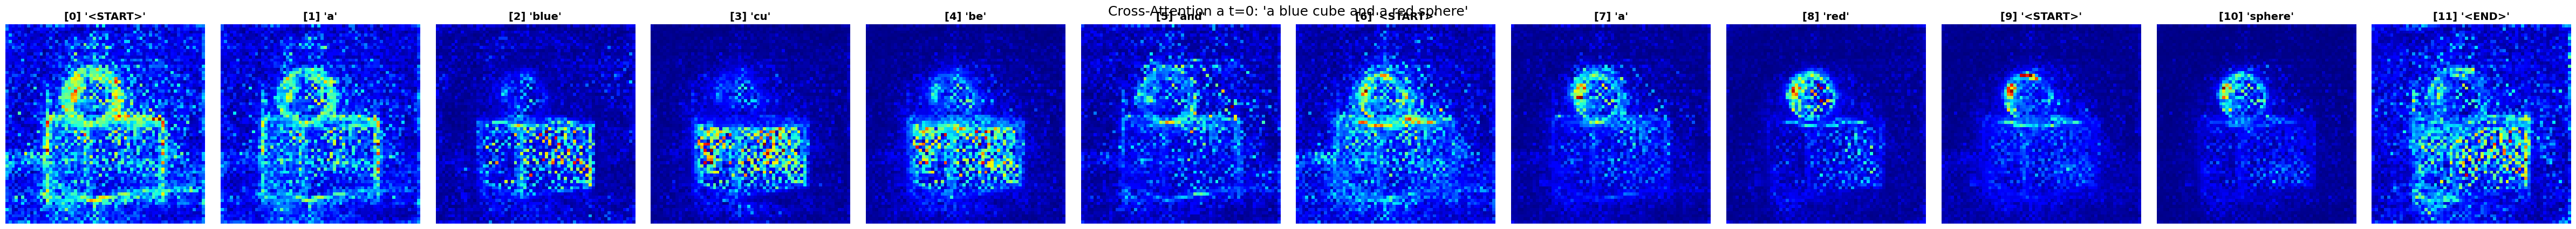

In [4]:
# 1. Eliminiamo il Batch e facciamo la media sulle 24 teste di attenzione
layer10 = attn['layer_10']
attn_mean = layer10[0].mean(dim=0) 

n_plot = len(token_utili)

# Prepariamo il grafico
fig, axes = plt.subplots(1, n_plot, figsize=(4 * n_plot, 4))
if n_plot == 1: axes = [axes] # Gestione caso singolo

for idx, token_id in enumerate(token_utili):
    # Decodifica il token
    parola = tokenizer.decode([token_id]).strip()
    if parola == "": parola = "<START>"
    if token_id.item() == 1: parola = "<END>"
    
    # Estraiamo la mappa per il singolo token (shape: [4096]) e ripieghiamo in 2D (64x64)
    token_map_flat = attn_mean[:, idx]
    token_map_2d = token_map_flat.view(64, 64).float().numpy()
    
    # Disegniamo la heatmap
    ax = axes[idx]
    im = ax.imshow(token_map_2d, cmap='jet')
    
    ax.set_title(f"[{idx}] '{parola}'", fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.suptitle(f"Cross-Attention a t=0: '{prompt_text}'", fontsize=18, y=1.05)
plt.show()


### 1.3 Correlazione Geometrica: L'Obiettivo Predetto ($x_{pred}$)

Prima di analizzare l'energia del movimento, diamo un'occhiata a *cosa* il modello sta cercando di costruire nello spazio latente allo step 0. 
In un framework ODE come FLUX, il modello riceve rumore puro ($x_1$) e predice direttamente il latente finale pulito ($x_{pred}$). Sebbene l'immagine sia poi generata decodificando questo latente con un VAE, possiamo avere un'intuizione chiara della "forma" grezza dell'oggetto nello spazio latente calcolando la magnitudo spaziale (Norma $L_2$) dei 64 canali vettoriali per ogni coordinata $64 \times 64$.

Questa operazione ci restituisce la "sagoma" geometrica statica (la planimetria strutturale) attesa dal modello.

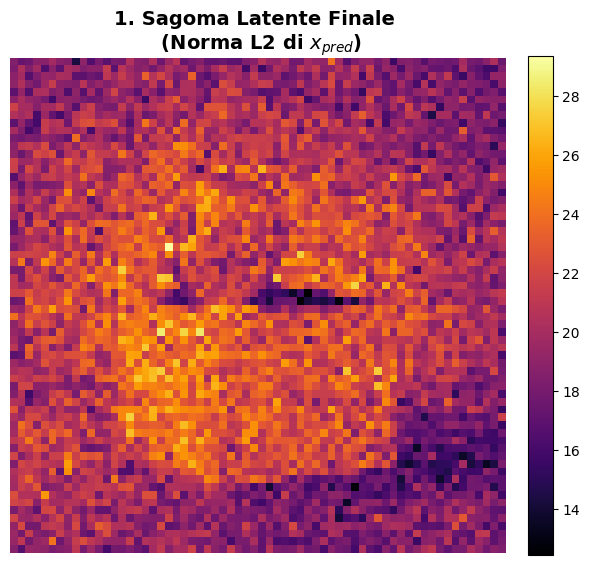

In [9]:
# 1. Calcolo della Magnitudo Fisica di x_pred (Norma L2 sui 64 canali)
# x_pred shape: [1, 4096, 64]
xpred_magnitude = torch.norm(x_pred, p=2, dim=-1)

# 2. Reshape in 2D (64x64) per la visualizzazione
xpred_img = xpred_magnitude.squeeze(0).view(64, 64).float().numpy()

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(xpred_img, cmap='inferno')
plt.title("1. Sagoma Latente Finale \n (Norma L2 di $x_{pred}$)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 1.4 Correlazione Termodinamica: Lo Spostamento Fisico ($v_0$)

Fino ad ora abbiamo esplorato come il modello "pensa" (tramite l'attenzione) e l'oggetto geometrico statico che vuole generare ($x_{pred}$). Ora dobbiamo verificare l'effettivo "Spostamento Fisico" compiuto dal denoiser. Nella formulazione ODE di Flux, il campo vettoriale predittivo $v_0$ definisce la traiettoria differenziale che trasporta la distribuzione di rumore puro $x_1$ verso la distribuzione target dei dati $x_0$.

In altre parole, il campo vettoriale $v_0$ rappresenta *l'energia termodinamica* applicata dal modello su ogni punto dello spazio latente per allontanarlo dal vuoto (rumore) e plasmare la figura. Misuriamo la magnitudo (Norma $L_2$) di questi vettori per capire dove si concentra lo sforzo generativo.

### 1.4.1 — Formalizzazione Accademica: Kinetic Path Energy (KPE) e Flow Matching

Secondo la recente letteratura (Li et al., 2026; "A Kinetic-Energy Perspective of Flow Matching"), il processo di generazione può essere visto attraverso una lente fisica come il trasporto di una particella lungo un campo vettoriale di velocità $v_\theta(x, t)$.

L'**Energia Cinetica di Percorso (KPE)** è definita come l'integrale temporale della norma quadratica della velocità:
$$E := \frac{1}{2} \int_0^1 \|v_\theta(x(t), t)\|^2 dt$$

In questo notebook, analizziamo $v_0$ (la velocità al tempo $t=0$), che rappresenta lo sforzo cinetico iniziale richiesto per "lanciare" la generazione fuori dalla distribuzione del rumore gaussiano verso il manifold dei dati. Un'elevata magnitudo di $v_0$ in regioni specifiche indica una forte spinta semantica verso target complessi o rari.

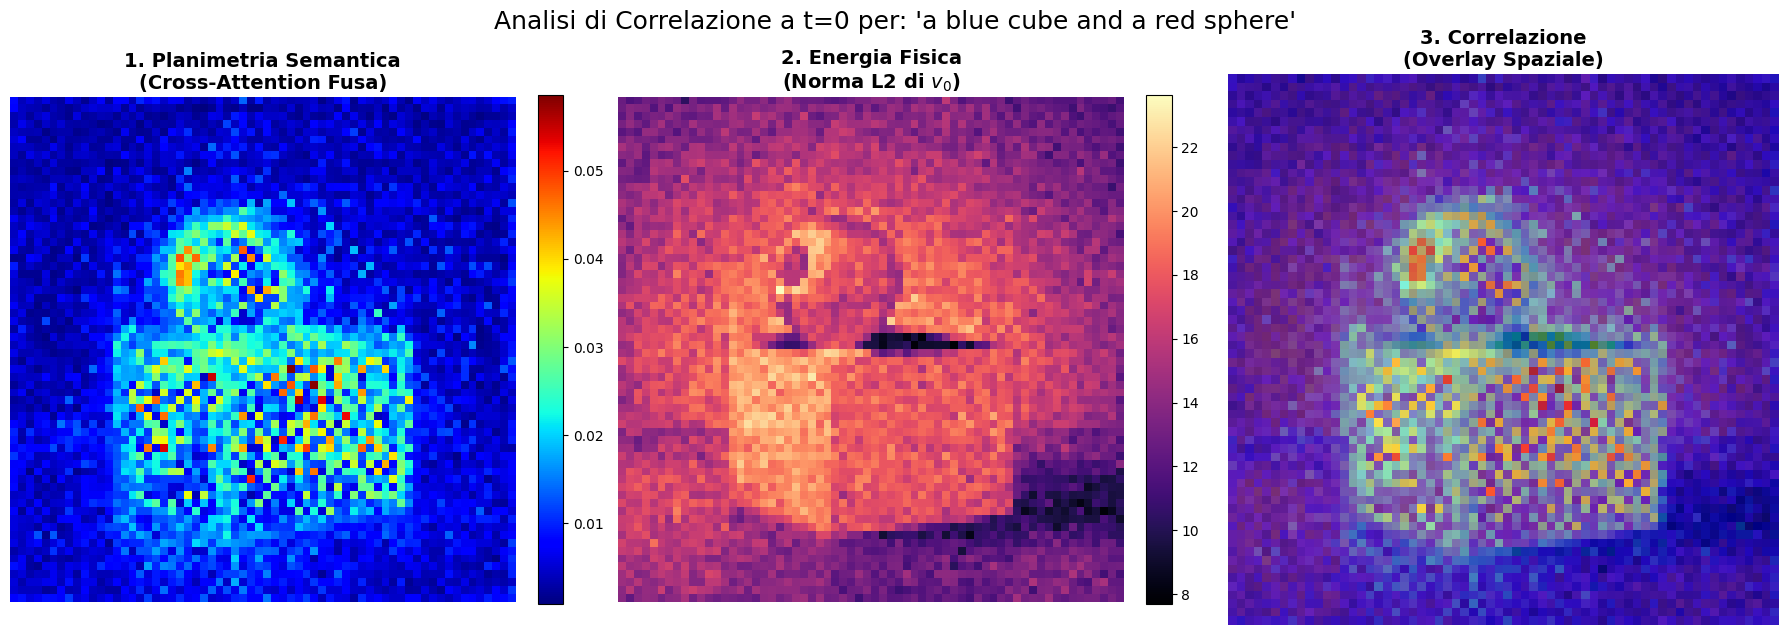

In [6]:
# 1. Calcolo della Magnitudo Fisica di v0 (Norma L2 sui 64 canali latenti)
# v0_velocity shape: [1, 4096, 64]
v0_magnitude = torch.norm(v0_velocity, p=2, dim=-1).squeeze(0) # shape: [4096]
v0_magnitude_2d = v0_magnitude.view(64, 64).float().numpy()

# 2. Creiamo una mappa di Attenzione Globale per l'oggetto (Fusione Dinamica semplificata)
# Escludiamo i token di padding e ci concentriamo sul contenuto semantico effettivo.
# I token utili sono salvati in `token_utili` dalla cella precedente.
attn_oggetti_fusa = torch.zeros(4096)
# Attenzione: token_utili contiene anche l'ID 1 (<END>). Potrebbe catturare l'Attention Sink.
# Filtriamo i token di sistema per sommare solo il peso delle "parole".
for i, token_id in enumerate(token_utili):
    if token_id.item() not in [0, 1]: # Se non è <START> o <END>
        attn_oggetti_fusa += attn_mean[:, i]

attn_oggetti_2d = attn_oggetti_fusa.view(64, 64).float().numpy()

# 3. Visualizzazione Comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Heatmap dell'Attenzione Semantica Fusa
im0 = axes[0].imshow(attn_oggetti_2d, cmap='jet')
axes[0].set_title("1. Planimetria Semantica\n(Cross-Attention Fusa)", fontsize=14, fontweight='bold')
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Heatmap della Magnitudo Fisica di v0
im1 = axes[1].imshow(v0_magnitude_2d, cmap='magma')
axes[1].set_title(f"2. Energia Fisica\n(Norma L2 di $v_0$)", fontsize=14, fontweight='bold')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Sovrapposizione (Overlay) per valutare la correlazione spaziale
axes[2].imshow(v0_magnitude_2d, cmap='magma')
# Sovrapponiamo l'attenzione come layer semi-trasparente.
axes[2].imshow(attn_oggetti_2d, cmap='jet', alpha=0.5) 
axes[2].set_title("3. Correlazione\n(Overlay Spaziale)", fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.suptitle(f"Analisi di Correlazione a t=0 per: '{prompt_text}'", fontsize=18, y=1.05)
plt.show()

### 1.5 Conclusioni Formali: Attenzione vs $x_{pred}$ vs Campo Vettoriale $v_0$

I risultati topologici generati rivelano una asimmetria comportamentale fondamentale per il nostro obiettivo di estrazione dell'oggetto dal suo background originale:

1.  **L'Attenzione come Mappa Concettuale (Sfocata):** Le Heatmaps di Cross-Attention individuano in maniera robusta le coordinate dell'oggetto bersaglio. Tuttavia, le "planimetrie" che producono sono sfocate e prive di contorni geometrici netti. L'attenzione definisce il "Dove" e il "Cosa", ma fallisce nel definire i "Limiti" esatti (i bordi).
2.  **$x_{pred}$ e $v_0$ come Entità Solide (Definite):** Al contrario, le mappe di energia vettoriale (la Norma $L_2$ di $x_{pred}$ e di $v_0$) descrivono la topologia fisica dell'immagine in modo netto. L'energia di trasporto è massima all'interno dell'oggetto e decresce ripidamente ai suoi bordi.

**Deduzione Logica per il FlowStitch:**
Dato che l'obiettivo del "Latent Stitching" è sostituire chirurgicamente lo sfondo preservando i bordi nativi del target, non possiamo affidarci esclusivamente alle maschere sfuocate estratte dall'Attenzione. L'energia di predizione mostra una correlazione fisica perfetta con i confini dell'oggetto.

Tuttavia, prima ancora di chiederci *come* creare una maschera (se binaria o sfumata), dobbiamo affrontare un problema fisico ancor più basilare: *cosa* stiamo effettivamente manipolando? 
Nel prossimo notebook (**Capitolo 2: La Variabile di Stato**), indagheremo quale sia l'entità matematica corretta da incollare: il latente predetto finale ($x_{pred}$) o la sua derivata temporale ($v_0$).